<a href="https://colab.research.google.com/github/palak0626/deep-learning/blob/main/projectdl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## SECTION 1 — Install & Import

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn kaggle --quiet
!pip install accelerate -U --quiet

In [2]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset as HFDataset

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [3]:
from google.colab import files
print('Upload mtsamples.csv:')
uploaded = files.upload()
!mkdir -p /content/data
!mv mtsamples.csv /content/data/

Upload mtsamples.csv:


Saving mtsamples.csv to mtsamples.csv


In [4]:
df = pd.read_csv('/content/data/mtsamples.csv', index_col=0)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (4999, 5)


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [5]:
print('Columns:', df.columns.tolist())
print('\nNull counts:')
print(df.isnull().sum())

Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Null counts:
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [6]:
specialty_counts = df['medical_specialty'].value_counts()
print(f'Total specialties: {len(specialty_counts)}')
print(specialty_counts)

Total specialties: 40
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic /

/tmp/ipykernel_755/2163709513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_specialties.values, y=top_specialties.index, palette='Blues_r')


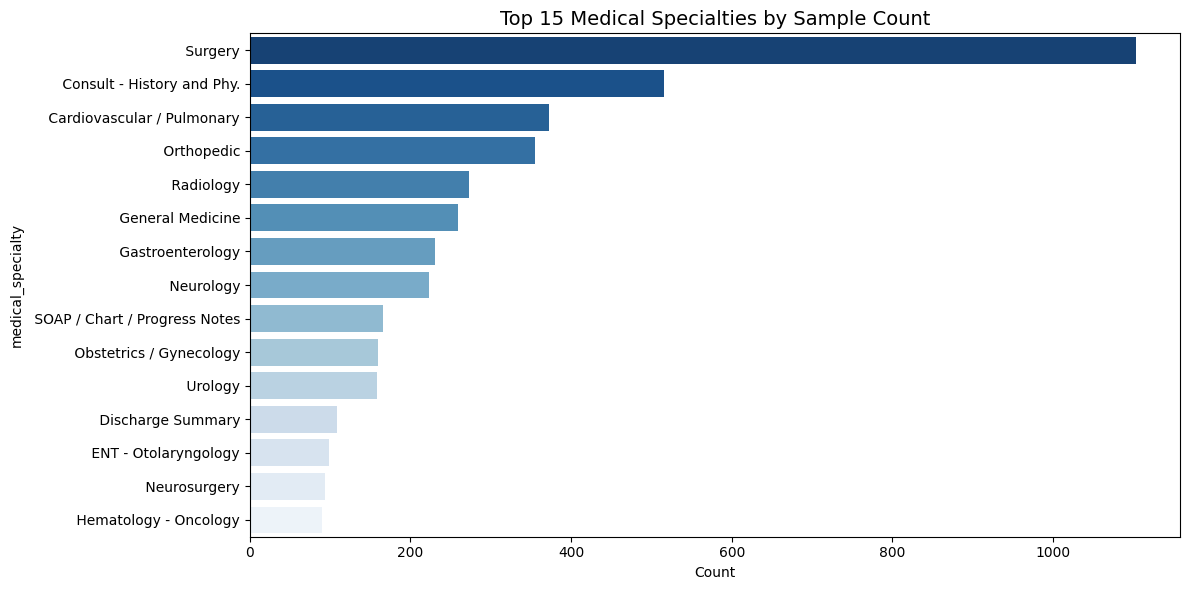

In [7]:
top_n = 15
top_specialties = specialty_counts.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_specialties.values, y=top_specialties.index, palette='Blues_r')
plt.title(f'Top {top_n} Medical Specialties by Sample Count', fontsize=14)
plt.xlabel('Count')
plt.tight_layout()
plt.show()

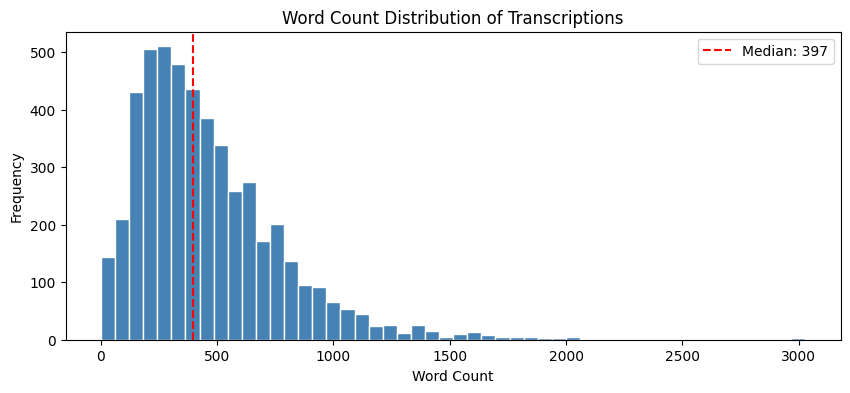

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: text_len, dtype: float64


In [8]:
df['text_len'] = df['transcription'].fillna('').apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
plt.hist(df['text_len'], bins=50, color='steelblue', edgecolor='white')
plt.title('Word Count Distribution of Transcriptions')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(df['text_len'].median(), color='red', linestyle='--', label=f'Median: {df["text_len"].median():.0f}')
plt.legend()
plt.show()

print(df['text_len'].describe())

In [11]:

import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)


drive_zip_path = "/content/drive/MyDrive/dlproject/archive (8).zip"
local_zip_path = "/content/archive.zip"
extract_dir = "/content/data2"


os.makedirs(extract_dir, exist_ok=True)


print("Copying ZIP from Google Drive...")
!cp "{drive_zip_path}" "{local_zip_path}"


if os.path.exists(local_zip_path):
    print("ZIP copied successfully!")
else:
    print("Error: ZIP not found after copying")


print("Extracting ZIP file...")
!unzip -o -q "{local_zip_path}" -d "{extract_dir}"

print("Extraction completed!")

print("\nChecking extracted files...")
file_count = 0

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        file_count += 1

print(f"Total files extracted: {file_count}")

csv_files = []

for root, dirs, files in os.walk(extract_dir):
    for fname in files:
        if fname.endswith('.csv'):
            csv_files.append(os.path.join(root, fname))

print(f"CSV files found: {len(csv_files)}")

print("\nSample CSV files:")
for f in csv_files[:5]:
    print(f)

Mounted at /content/drive
Copying ZIP from Google Drive...
ZIP copied successfully!
Extracting ZIP file...
replace /content/data2/Medical Speech, Transcription, and Intent/overview-of-recordings.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
Extraction completed!

Checking extracted files...
Total files extracted: 4696
CSV files found: 1

Sample CSV files:
/content/data2/Medical Speech, Transcription, and Intent/overview-of-recordings.csv


In [13]:
# import zipfile, os
# from google.colab import drive


# drive.mount('/content/drive')


# ZIP_PATH = '/content/drive/MyDrive/dlproject/archive (8).zip'



# extract_dir = '/content/data2'
# os.makedirs(extract_dir, exist_ok=True)

# print(f"Reading ZIP from Drive: {ZIP_PATH}")
# with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
#     print("Contents of ZIP:")
#     zf.printdir()
#     zf.extractall(extract_dir)

# print(f"\nExtracted to {extract_dir}")


# csv_files = []
# for root, dirs, files_ in os.walk(extract_dir):
#     for fname in files_:
#         if fname.endswith('.csv'):
#             csv_files.append(os.path.join(root, fname))

# print(f"CSV files found: {csv_files}")


if csv_files:
    csv_path = csv_files[0]
    df2_raw = pd.read_csv(csv_path)
    print(f"\nLoaded: {csv_path}")
    print(f"Dataset 2 shape: {df2_raw.shape}")
    print("Columns:", df2_raw.columns.tolist())
    display(df2_raw.head(3))
else:
    raise FileNotFoundError("No CSV found. Check your ZIP_PATH above.")


Loaded: /content/data2/Medical Speech, Transcription, and Intent/overview-of-recordings.csv
Dataset 2 shape: (6661, 13)
Columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']


,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353


In [14]:
TEXT_COL2  = 'phrase'
LABEL_COL2 = 'prompt'

df2 = df2_raw[[TEXT_COL2, LABEL_COL2]].copy()
df2.columns = ['input_text', 'medical_specialty']
df2 = df2.dropna()
df2['medical_specialty'] = df2['medical_specialty'].str.strip().str.title()

print(f"Dataset 2 — {len(df2)} samples across {df2['medical_specialty'].nunique()} specialties")
print(df2['medical_specialty'].value_counts().head(15))

Dataset 2 — 6661 samples across 25 specialties
medical_specialty
Acne                328
Shoulder Pain       320
Joint Pain          318
Infected Wound      306
Knee Pain           305
Cough               293
Feeling Dizzy       283
Muscle Pain         282
Heart Hurts         273
Ear Ache            270
Hair Falling Out    264
Feeling Cold        263
Head Ache           263
Skin Issue          262
Stomach Ache        261
Name: count, dtype: int64


In [15]:
df1 = df[['description', 'transcription', 'medical_specialty']].copy()
df1['medical_specialty'] = df1['medical_specialty'].str.strip().str.title()

def get_input_text_ds1(row):
    desc  = str(row.get('description',  '') or '')
    trans = str(row.get('transcription','') or '')
    return desc if len(desc.split()) >= 10 else ' '.join(trans.split()[:200])

df1['input_text'] = df1.apply(get_input_text_ds1, axis=1)
df1 = df1[['input_text', 'medical_specialty']]
df1['source'] = 'mtsamples'


df2['source'] = 'speech_intent'

df_combined = pd.concat([df1, df2], ignore_index=True)
df_combined = df_combined.dropna(subset=['input_text', 'medical_specialty'])
df_combined = df_combined[df_combined['input_text'].str.strip().str.len() > 10]

print(f"Dataset 1 size : {len(df1)}")
print(f"Dataset 2 size : {len(df2)}")
print(f"Combined size  : {len(df_combined)}")
print(f"Unique specialties before filtering: {df_combined['medical_specialty'].nunique()}")

Dataset 1 size : 4999
Dataset 2 size : 6661
Combined size  : 11624
Unique specialties before filtering: 65


Specialties in BOTH datasets : 0
Only in mtsamples            : 40
Only in speech-intent        : 25

Overlapping: []


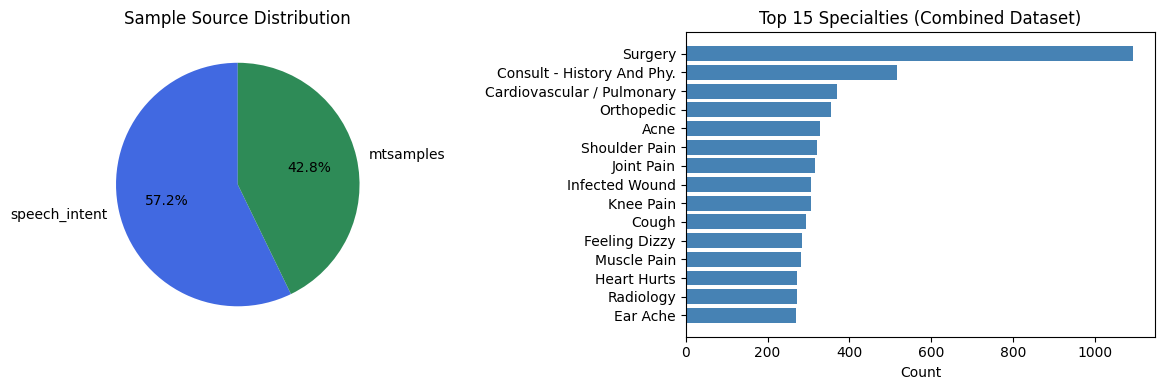

In [16]:
sp1 = set(df1['medical_specialty'].unique())
sp2 = set(df2['medical_specialty'].unique())

overlap  = sp1 & sp2
only_ds1 = sp1 - sp2
only_ds2 = sp2 - sp1

print(f"Specialties in BOTH datasets : {len(overlap)}")
print(f"Only in mtsamples            : {len(only_ds1)}")
print(f"Only in speech-intent        : {len(only_ds2)}")
print(f"\nOverlapping: {sorted(overlap)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

src_counts = df_combined['source'].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%',
            colors=['royalblue','seagreen'], startangle=90)
axes[0].set_title('Sample Source Distribution')

top15 = df_combined['medical_specialty'].value_counts().head(15)
axes[1].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[1].set_title('Top 15 Specialties (Combined Dataset)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('/content/combined_dataset_eda.png', dpi=150)
plt.show()

In [17]:
TOP_K = 10

top_classes = df_combined['medical_specialty'].value_counts().head(TOP_K).index.tolist()
df_filtered = df_combined[df_combined['medical_specialty'].isin(top_classes)].copy()

print(f"Kept {TOP_K} specialties → {len(df_filtered)} samples")
print(df_filtered['medical_specialty'].value_counts())
print(f"\nSource breakdown after filtering:")
print(df_filtered['source'].value_counts())

Kept 10 specialties → 4204 samples
medical_specialty
Surgery                       1093
Consult - History And Phy.     516
Cardiovascular / Pulmonary     371
Orthopedic                     355
Acne                           328
Shoulder Pain                  320
Joint Pain                     317
Infected Wound                 306
Knee Pain                      305
Cough                          293
Name: count, dtype: int64

Source breakdown after filtering:
source
mtsamples        2335
speech_intent    1869
Name: count, dtype: int64


In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.,;]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['clean_text'] = df_filtered['input_text'].apply(clean_text)

le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['medical_specialty'])

NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print("Label mapping:", dict(enumerate(le.classes_)))

Number of classes: 10
Label mapping: {0: 'Acne', 1: 'Cardiovascular / Pulmonary', 2: 'Consult - History And Phy.', 3: 'Cough', 4: 'Infected Wound', 5: 'Joint Pain', 6: 'Knee Pain', 7: 'Orthopedic', 8: 'Shoulder Pain', 9: 'Surgery'}


Train: 2942 | Val: 631 | Test: 631


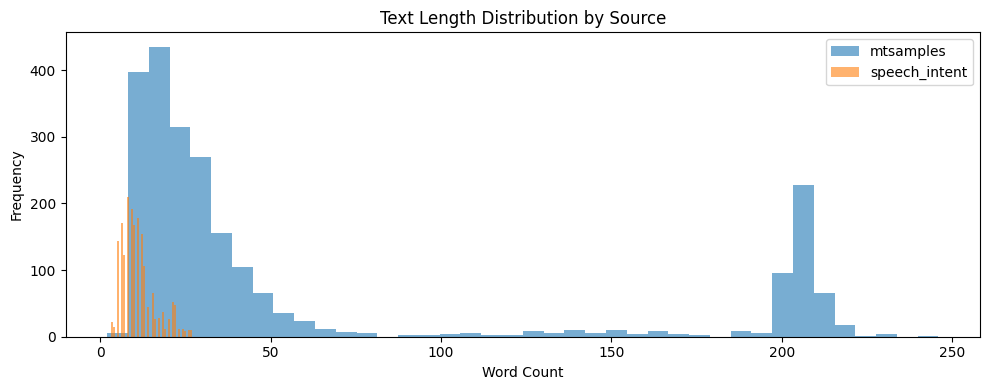

In [19]:
X = df_filtered['clean_text'].tolist()
y = df_filtered['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

df_filtered['text_len'] = df_filtered['clean_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 4))
for src, grp in df_filtered.groupby('source'):
    plt.hist(grp['text_len'], bins=40, alpha=0.6, label=src)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Text Length Distribution by Source')
plt.legend()
plt.tight_layout()
plt.savefig('/content/text_length_by_source.png', dpi=150)
plt.show()

## LSTM

In [20]:
!wget -q --show-progress http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
!unzip -q /content/glove.6B.zip -d /content/glove/
print('GloVe downloaded!')

/content/glove.6B.z 100%[===================>] 822.24M  5.06MB/s    in 2m 58s  
GloVe downloaded!


In [21]:
VOCAB_SIZE = 20000
EMBED_DIM = 100
MAX_LEN = 150
PAD_IDX = 0
UNK_IDX = 1

def tokenize(text):
    return text.split()

counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

vocab = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

print(f'Vocabulary size: {len(vocab)}')

Vocabulary size: 13007


In [22]:
def load_glove(path):
    glove = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            glove[word] = vector
    return glove

print('Loading GloVe...')
glove_vectors = load_glove(f'/content/glove/glove.6B.{EMBED_DIM}d.txt')
print(f'GloVe loaded: {len(glove_vectors)} words')

embed_matrix = np.zeros((len(vocab), EMBED_DIM), dtype='float32')
for word, idx in vocab.items():
    if word in glove_vectors:
        embed_matrix[idx] = glove_vectors[word]
    elif idx == UNK_IDX:
        embed_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)

print(f'Embedding matrix shape: {embed_matrix.shape}')


covered = sum(1 for w in vocab if w in glove_vectors)
print(f'Vocab coverage by GloVe: {covered/len(vocab)*100:.1f}%')

Loading GloVe...
GloVe loaded: 400000 words
Embedding matrix shape: (13007, 100)
Vocab coverage by GloVe: 48.2%


In [23]:
def text_to_seq(text, vocab, max_len):
    tokens = tokenize(text)[:max_len]
    seq = [vocab.get(t, UNK_IDX) for t in tokens]
    # Pad / truncate
    seq = seq + [PAD_IDX] * (max_len - len(seq))
    return seq

X_train_seq = np.array([text_to_seq(t, vocab, MAX_LEN) for t in X_train])
X_val_seq   = np.array([text_to_seq(t, vocab, MAX_LEN) for t in X_val])
X_test_seq  = np.array([text_to_seq(t, vocab, MAX_LEN) for t in X_test])

print('Sequence shapes:', X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

Sequence shapes: (2942, 150) (631, 150) (631, 150)


In [24]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_ds = TextDataset(X_train_seq, y_train)
val_ds   = TextDataset(X_val_seq,   y_val)
test_ds  = TextDataset(X_test_seq,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print('DataLoaders ready.')

DataLoaders ready.


In [25]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_matrix,
                 hidden_dim=256, num_layers=2, num_classes=10,
                 dropout=0.4, freeze_embed=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight = nn.Parameter(torch.tensor(embed_matrix))
        if freeze_embed:
            self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        hidden = self.layer_norm(hidden)
        hidden = self.dropout(hidden)

        return self.fc(hidden)


lstm_model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    embed_matrix=embed_matrix,
    hidden_dim=256,
    num_layers=2,
    num_classes=NUM_CLASSES,
    dropout=0.4
).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'BiLSTM model — trainable params: {total_params:,}')
print(lstm_model)

BiLSTM model — trainable params: 3,678,822
BiLSTMClassifier(
  (embedding): Embedding(13007, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (fc): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [26]:

def train_lstm(model, train_loader, val_loader, epochs=15, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0
    PATIENCE = 4

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                out = model(X_batch)
                val_loss += criterion(out, y_batch).item()
                correct += (out.argmax(1) == y_batch).sum().item()
                total += y_batch.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        scheduler.step(avg_val_loss)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '/content/best_lstm.pt')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch+1}')
                break

    print(f'\nBest Val Accuracy: {best_val_acc:.4f}')
    return history


print('Training BiLSTM...')
lstm_history = train_lstm(lstm_model, train_loader, val_loader, epochs=20)

Training BiLSTM...
Epoch 01/20 | Train Loss: 1.6267 | Val Loss: 1.1665 | Val Acc: 0.5151
Epoch 02/20 | Train Loss: 1.0907 | Val Loss: 0.8646 | Val Acc: 0.6292
Epoch 03/20 | Train Loss: 0.8253 | Val Loss: 0.6820 | Val Acc: 0.6561
Epoch 04/20 | Train Loss: 0.6638 | Val Loss: 0.5536 | Val Acc: 0.7670
Epoch 05/20 | Train Loss: 0.5551 | Val Loss: 0.4968 | Val Acc: 0.7892
Epoch 06/20 | Train Loss: 0.4626 | Val Loss: 0.4868 | Val Acc: 0.7861
Epoch 07/20 | Train Loss: 0.4107 | Val Loss: 0.4600 | Val Acc: 0.7971
Epoch 08/20 | Train Loss: 0.3631 | Val Loss: 0.4892 | Val Acc: 0.8003
Epoch 09/20 | Train Loss: 0.3259 | Val Loss: 0.4745 | Val Acc: 0.7971
Epoch 10/20 | Train Loss: 0.3212 | Val Loss: 0.5095 | Val Acc: 0.8003
Epoch 11/20 | Train Loss: 0.2641 | Val Loss: 0.5626 | Val Acc: 0.8003
Epoch 12/20 | Train Loss: 0.2421 | Val Loss: 0.5635 | Val Acc: 0.7908
Early stopping at epoch 12

Best Val Accuracy: 0.8003


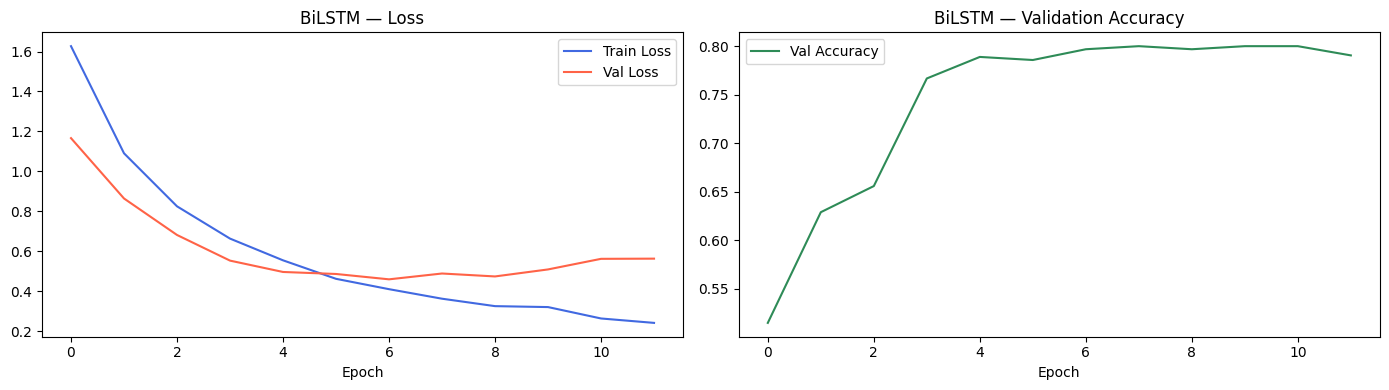

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(lstm_history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(lstm_history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('BiLSTM — Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(lstm_history['val_acc'], label='Val Accuracy', color='seagreen')
ax2.set_title('BiLSTM — Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/lstm_training_curves.png', dpi=150)
plt.show()

In [28]:
def evaluate_model(model, loader, label_names):
    model.eval()
    all_preds, all_labels = [], []
    start = time.time()

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.numpy())

    elapsed = time.time() - start
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')

    print(f'Accuracy: {acc:.4f}  |  Macro F1: {f1:.4f}  |  Inference time: {elapsed:.2f}s')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds, target_names=label_names))

    return all_labels, all_preds, acc, f1, elapsed

lstm_model.load_state_dict(torch.load('/content/best_lstm.pt'))
print('=== BiLSTM — Test Evaluation ===')
lstm_labels, lstm_preds, lstm_acc, lstm_f1, lstm_time = evaluate_model(lstm_model, test_loader, le.classes_)

=== BiLSTM — Test Evaluation ===
Accuracy: 0.7797  |  Macro F1: 0.7991  |  Inference time: 0.19s

Classification Report:
                            precision    recall  f1-score   support

                      Acne       0.98      1.00      0.99        49
Cardiovascular / Pulmonary       0.42      0.50      0.46        56
Consult - History And Phy.       0.64      0.61      0.63        77
                     Cough       1.00      1.00      1.00        44
            Infected Wound       0.98      1.00      0.99        46
                Joint Pain       1.00      1.00      1.00        48
                 Knee Pain       1.00      1.00      1.00        46
                Orthopedic       0.47      0.13      0.21        53
             Shoulder Pain       1.00      1.00      1.00        48
                   Surgery       0.66      0.79      0.72       164

                  accuracy                           0.78       631
                 macro avg       0.82      0.80      0.80    

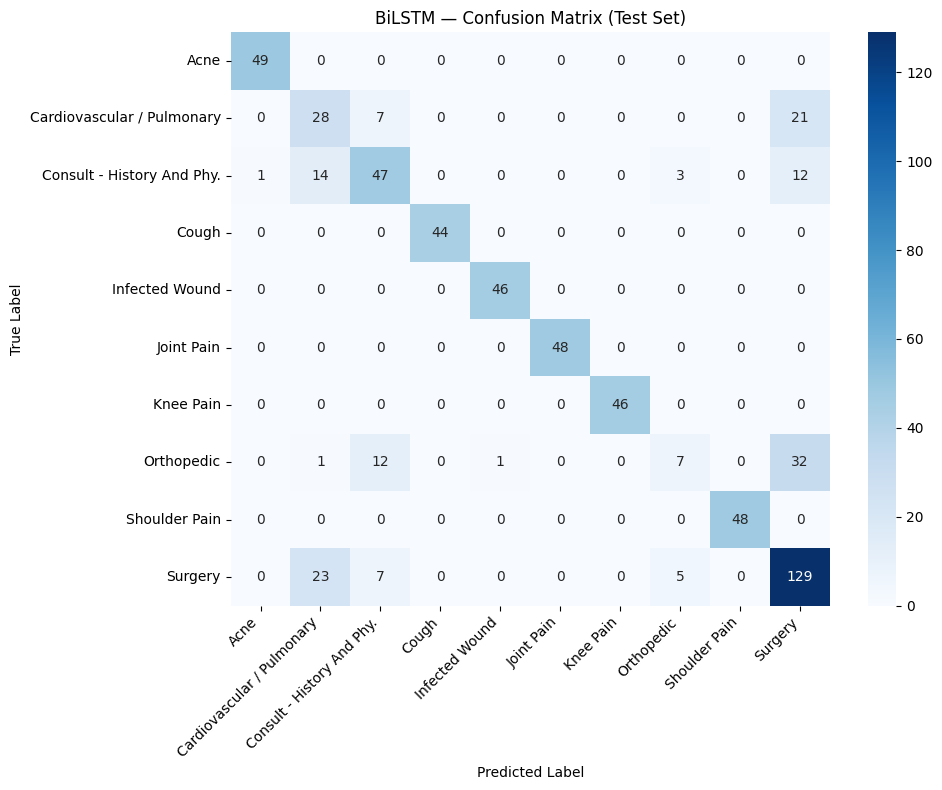

In [29]:

cm = confusion_matrix(lstm_labels, lstm_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('BiLSTM — Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/lstm_confusion_matrix.png', dpi=150)
plt.show()

In [30]:

MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
BERT_MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Loaded tokenizer: {MODEL_NAME}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded tokenizer: dmis-lab/biobert-base-cased-v1.2


In [31]:

def tokenize_batch(texts, labels):
    enc = tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=BERT_MAX_LEN,
        return_tensors='pt'
    )
    enc['labels'] = torch.tensor(labels, dtype=torch.long)
    return enc

def make_hf_dataset(texts, labels):
    enc = tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=BERT_MAX_LEN
    )
    return HFDataset.from_dict({
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'token_type_ids': enc.get('token_type_ids', [[0]*BERT_MAX_LEN]*len(texts)),
        'labels': labels
    })

print('Tokenizing splits...')
bert_train_ds = make_hf_dataset(X_train, y_train)
bert_val_ds   = make_hf_dataset(X_val,   y_val)
bert_test_ds  = make_hf_dataset(X_test,  y_test)
print('Done!')

Tokenizing splits...
Done!


In [32]:

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
bert_model = bert_model.to(device)

bert_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f'BioBERT — trainable params: {bert_params:,}')

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BioBERT — trainable params: 108,317,962


In [33]:

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro')
    }

In [34]:

training_args = TrainingArguments(
    output_dir='/content/biobert_output',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_ds,
    eval_dataset=bert_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Starting BioBERT fine-tuning...')
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting BioBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.736438,0.623053,0.797147,0.794467
2,0.404962,0.397768,0.816165,0.857966
3,0.263261,0.384090,0.817750,0.840128
4,0.260064,0.433129,0.803487,0.835037


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=736, training_loss=0.6124776789675588, metrics={'train_runtime': 172.0976, 'train_samples_per_second': 85.475, 'train_steps_per_second': 5.346, 'total_flos': 774128325562368.0, 'train_loss': 0.6124776789675588, 'epoch': 4.0})

In [35]:
print('=== BioBERT — Test Evaluation ===')
start = time.time()
bert_preds_out = trainer.predict(bert_test_ds)
bert_time = time.time() - start

bert_pred_labels = np.argmax(bert_preds_out.predictions, axis=1)
bert_true_labels = bert_preds_out.label_ids

bert_acc = accuracy_score(bert_true_labels, bert_pred_labels)
bert_f1  = f1_score(bert_true_labels, bert_pred_labels, average='macro')

print(f'Accuracy: {bert_acc:.4f}  |  Macro F1: {bert_f1:.4f}  |  Inference time: {bert_time:.2f}s')
print('\nClassification Report:')
print(classification_report(bert_true_labels, bert_pred_labels, target_names=le.classes_))

=== BioBERT — Test Evaluation ===


Accuracy: 0.8241  |  Macro F1: 0.8645  |  Inference time: 1.25s

Classification Report:
                            precision    recall  f1-score   support

                      Acne       0.98      1.00      0.99        49
Cardiovascular / Pulmonary       0.51      0.77      0.61        56
Consult - History And Phy.       0.76      0.70      0.73        77
                     Cough       1.00      1.00      1.00        44
            Infected Wound       1.00      1.00      1.00        46
                Joint Pain       1.00      1.00      1.00        48
                 Knee Pain       1.00      1.00      1.00        46
                Orthopedic       0.54      0.62      0.58        53
             Shoulder Pain       1.00      1.00      1.00        48
                   Surgery       0.83      0.66      0.74       164

                  accuracy                           0.82       631
                 macro avg       0.86      0.88      0.86       631
              weighted avg

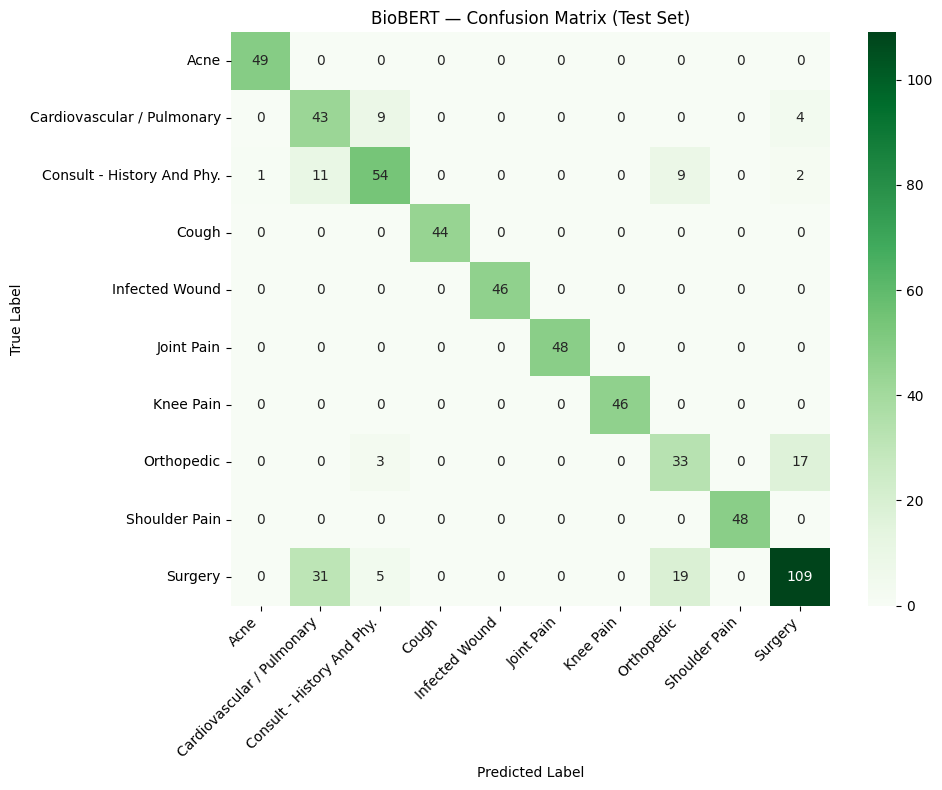

In [36]:
cm_bert = confusion_matrix(bert_true_labels, bert_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('BioBERT — Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/bert_confusion_matrix.png', dpi=150)
plt.show()


## Model Comparison

In [37]:
results = pd.DataFrame({
    'Model':          ['BiLSTM + GloVe', 'BioBERT (fine-tuned)'],
    'Test Accuracy':  [f'{lstm_acc:.4f}', f'{bert_acc:.4f}'],
    'Macro F1':       [f'{lstm_f1:.4f}',  f'{bert_f1:.4f}'],
    'Inference (s)':  [f'{lstm_time:.2f}', f'{bert_time:.2f}'],
    'Params':         [f'{total_params:,}', f'{bert_params:,}']
})

print('\n' + '='*60)
print('           FINAL MODEL COMPARISON')
print('='*60)
print(results.to_string(index=False))
print('='*60)


           FINAL MODEL COMPARISON
               Model Test Accuracy Macro F1 Inference (s)      Params
      BiLSTM + GloVe        0.7797   0.7991          0.19   3,678,822
BioBERT (fine-tuned)        0.8241   0.8645          1.25 108,317,962


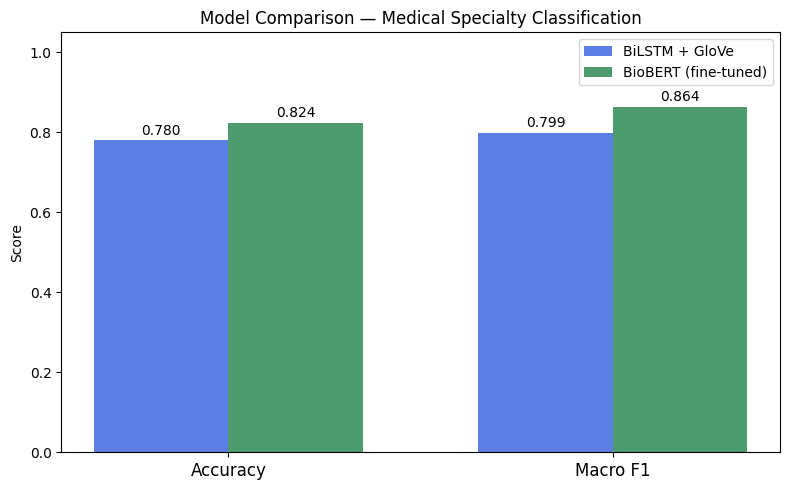

In [38]:
metrics = ['Accuracy', 'Macro F1']
lstm_scores = [lstm_acc, lstm_f1]
bert_scores = [bert_acc, bert_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, lstm_scores, width, label='BiLSTM + GloVe', color='royalblue', alpha=0.85)
bars2 = ax.bar(x + width/2, bert_scores, width, label='BioBERT (fine-tuned)', color='seagreen', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Medical Specialty Classification')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150)
plt.show()

In [41]:

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output


def predict_lstm(text):
    lstm_model.eval()
    cleaned = clean_text(text)
    seq = torch.tensor([text_to_seq(cleaned, vocab, MAX_LEN)], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = lstm_model(seq)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    top_idx   = probs.argmax()
    pred_cls  = le.classes_[top_idx]
    confidence = float(probs[top_idx])
    top5 = sorted(zip(le.classes_, probs), key=lambda x: -x[1])[:5]
    return pred_cls, confidence, top5

def predict_bert(text):
    bert_model.eval()
    enc = tokenizer(
        text, return_tensors='pt',
        padding='max_length', truncation=True,
        max_length=BERT_MAX_LEN
    ).to(device)
    with torch.no_grad():
        out   = bert_model(**enc)
        probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
    top_idx    = probs.argmax()
    pred_cls   = le.classes_[top_idx]
    confidence = float(probs[top_idx])
    top5 = sorted(zip(le.classes_, probs), key=lambda x: -x[1])[:5]
    return pred_cls, confidence, top5

def conf_color(conf):
    if conf >= 0.75: return "#2ecc71"
    if conf >= 0.50: return "#f39c12"
    return "#e74c3c"

def top5_html(top5, model_name, pred_cls, conf):
    color = conf_color(conf)
    rows = ""
    for cls, p in top5:
        bar_w  = int(p * 100)
        bold   = "font-weight:bold;" if cls == pred_cls else ""
        rows += f"""
        <tr>
          <td style="padding:3px 10px 3px 0;{bold}width:160px">{cls}</td>
          <td style="width:200px">
            <div style="background:#ecf0f1;border-radius:4px;height:16px;">
              <div style="width:{bar_w}%;background:{conf_color(p)};
                          border-radius:4px;height:16px;"></div>
            </div>
          </td>
          <td style="padding-left:8px;{bold}">{p*100:.1f}%</td>
        </tr>"""

    return f"""
    <div style="border:1px solid #ddd;border-radius:8px;padding:14px;
                margin:6px;flex:1;min-width:280px;background:#fafafa;">
      <h4 style="margin:0 0 8px;color:#2c3e50">🔬 {model_name}</h4>
      <div style="font-size:22px;font-weight:bold;color:{color};margin-bottom:6px">
        {pred_cls}
      </div>
      <div style="font-size:13px;color:#555;margin-bottom:10px">
        Confidence: <b style="color:{color}">{conf*100:.1f}%</b>
      </div>
      <hr style="border:none;border-top:1px solid #ddd;margin:8px 0">
      <div style="font-size:12px;color:#777;margin-bottom:4px">Top-5 Probabilities</div>
      <table style="width:100%;font-size:13px">{rows}</table>
    </div>"""

SAMPLES = {
    "🫀 Chest Pain"      : "Patient presents with chest pain radiating to the left arm, shortness of breath, and diaphoresis. History of hypertension.",
    "🧠 Neuro"           : "Sudden severe headache, blurred vision, confusion, and slurred speech. No prior history.",
    "🦴 Ortho"           : "Knee swelling after fall, difficulty bearing weight, tenderness over medial joint line.",
    "🫁 Respiratory"     : "Persistent dry cough for 3 weeks, mild fever, fatigue, and decreased oxygen saturation.",
    "🏥 Gastro"          : "Abdominal pain in the lower right quadrant, nausea, vomiting, and loss of appetite since yesterday.",
}

title_html = widgets.HTML("""
<div style="background:linear-gradient(135deg,#1a237e,#0288d1);
            padding:18px 24px;border-radius:10px;margin-bottom:12px">
  <h2 style="color:white;margin:0">🏥 Medical Specialty Triage — Live Demo</h2>
  <p  style="color:#bbdefb;margin:4px 0 0">
      Enter patient symptoms → get specialty prediction from BiLSTM & BioBERT
  </p>
</div>""")

symptom_box = widgets.Textarea(
    placeholder="e.g. Patient has severe chest pain, shortness of breath and dizziness...",
    layout=widgets.Layout(width="100%", height="100px")
)

predict_btn = widgets.Button(
    description="Predict Specialty",
    button_style="primary",
    icon="stethoscope",
    layout=widgets.Layout(width="200px", height="36px", margin="8px 0")
)

clear_btn = widgets.Button(
    description="Clear",
    button_style="warning",
    icon="times",
    layout=widgets.Layout(width="100px", height="36px", margin="8px 4px")
)

sample_label = widgets.HTML("<b>Quick samples:</b>")
sample_btns  = [
    widgets.Button(description=label, layout=widgets.Layout(margin="3px"))
    for label in SAMPLES
]

output_area = widgets.Output()

def on_predict(b):
    text = symptom_box.value.strip()
    if not text:
        with output_area:
            clear_output()
            display(HTML('<p style="color:red">⚠️ Please enter a symptom description first.</p>'))
        return

    with output_area:
        clear_output()
        display(HTML('<p style="color:#555;font-style:italic">⏳ Running models...</p>'))

    lstm_cls, lstm_conf, lstm_top5 = predict_lstm(text)
    bert_cls, bert_conf, bert_top5 = predict_bert(text)

    agree = lstm_cls == bert_cls
    badge_color = "#27ae60" if agree else "#e74c3c"
    badge_text  = "✅ Both models agree!" if agree else "⚠️ Models disagree"

    result_html = f"""
    <div style="font-family:sans-serif">
      <div style="background:{badge_color};color:white;padding:8px 14px;
                  border-radius:6px;margin-bottom:12px;font-weight:bold">
        {badge_text}
      </div>
      <div style="display:flex;gap:12px;flex-wrap:wrap">
        {top5_html(lstm_top5, "BiLSTM + GloVe",  lstm_cls, lstm_conf)}
        {top5_html(bert_top5, "BioBERT (fine-tuned)", bert_cls, bert_conf)}
      </div>
      <p style="font-size:12px;color:#aaa;margin-top:10px">
        Input ({len(text.split())} words): <i>"{text[:120]}{'...' if len(text)>120 else ''}"</i>
      </p>
    </div>"""

    with output_area:
        clear_output()
        display(HTML(result_html))

def on_clear(b):
    symptom_box.value = ""
    with output_area:
        clear_output()

def make_sample_handler(txt):
    def handler(b):
        symptom_box.value = txt
        on_predict(None)
    return handler

predict_btn.on_click(on_predict)
clear_btn.on_click(on_clear)
for btn, txt in zip(sample_btns, SAMPLES.values()):
    btn.on_click(make_sample_handler(txt))

sample_row = widgets.HBox([sample_label] + sample_btns,
                          layout=widgets.Layout(flex_flow="row wrap"))
btn_row    = widgets.HBox([predict_btn, clear_btn])

display(widgets.VBox([
    title_html,
    widgets.HTML("<b>Enter Patient Symptoms:</b>"),
    symptom_box,
    btn_row,
    sample_row,
    widgets.HTML("<hr style='border:none;border-top:1px solid #eee;margin:10px 0'>"),
    output_area
], layout=widgets.Layout(width="100%", padding="10px")))


In [40]:
import pickle

torch.save(lstm_model.state_dict(), '/content/final_lstm_model.pt')
with open('/content/lstm_vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

bert_model.save_pretrained('/content/final_biobert_model')
tokenizer.save_pretrained('/content/final_biobert_model')

print('All models saved!')
print('Files saved:')
print('  /content/final_lstm_model.pt')
print('  /content/lstm_vocab.pkl')
print('  /content/label_encoder.pkl')
print('  /content/final_biobert_model/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models saved!
Files saved:
  /content/final_lstm_model.pt
  /content/lstm_vocab.pkl
  /content/label_encoder.pkl
  /content/final_biobert_model/
